# Multi-Task Skin Lesion Diagnostic
This notebook sketches a PyTorch implementation of the architecture described in *Multi-Task Classification and Segmentation for Explicable Capsule Endoscopy Diagnostics*. The model shares an encoder across tasks and uses separate heads for frame-level classification and pixel-level lesion segmentation.

In [12]:
# Core libraries, torch modules, and torchvision utilities used throughout the notebook
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterator, List, Optional, Tuple
import random

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

# Fix random seed so the data augmentations and weight initialisation remain reproducible
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(69)


# Model configurations

In [13]:
# Configuration
@dataclass
class Config:
    """Central hyper-parameters mirroring the settings reported in the paper."""
    project_root: Path = Path.cwd()
    image_size: Tuple[int, int] = (224, 224)  # input resolution for both tasks
    batch_size: int = 16  # increased for Windows (was 8) - keeps GPU busy longer
    segmentation_batch_size: int = 8  # increased for Windows (was 4)
    gradient_accumulation_steps: int = 1  # set >1 if batch size causes OOM
    base_learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    max_epochs: int = 20
    alpha: float = 0.1  # fusion-penalty weight α used in the paper for regularisation
    classification_loss_weight: float = 0.6  # balance between classification and segmentation losses
    segmentation_loss_weight: float = 0.4
    class_names: Tuple[str, ...] = ("MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC")
    classification_hidden_dims: Tuple[int, int, int, int] = (1024, 512, 256, 128)
    num_segmentation_classes: int = 2
    trainable_backbone_layers: int = 3
    use_pretrained: bool = True
    ignore_index: int = 255  # optional label to mask out invalid pixels
    min_learning_rate: float = 1e-6
    scheduler_period: int = 10  # cosine-annealing period (epochs)
    mixed_precision: bool = True  # enable AMP when CUDA is available
    segmentation_positive_weight: float = 1.5  # kept for potential focal weighting experiments
    grad_clip_norm: Optional[float] = 5.0  # guard against exploding gradients
    imagenet_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406)
    imagenet_std: Tuple[float, float, float] = (0.229, 0.224, 0.225)
    segmentation_suffix: str = "_segmentation"
    dataset_root: Path = Path("multitask_fully_labeled")
    manifest_path: Path = Path("multitask_fully_labeled\manifest.csv")

    def get_split_data(self, split: str) -> pd.DataFrame:
        """Load and filter manifest for the given split."""
        df = pd.read_csv(self.manifest_path)
        return df[df["split"] == split].reset_index(drop=True)
    
cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Image utilites

In [14]:
# Data transforms
def build_classification_transform(cfg: Config, train: bool) -> transforms.Compose:
    """Compose the augmentations used for the image-level classifier."""
    augmentations: List[transforms.Compose]
    if train:
        augmentations = [
            # Random crops and flips mimic the appearance variability described in the paper
            transforms.RandomResizedCrop(cfg.image_size, scale=(0.8, 1.0), interpolation=InterpolationMode.BILINEAR),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        ]
    else:
        augmentations = [
            transforms.Resize(cfg.image_size, interpolation=InterpolationMode.BILINEAR),
            transforms.CenterCrop(cfg.image_size),
        ]
    augmentations += [
        transforms.ToTensor(),
        transforms.Normalize(mean=cfg.imagenet_mean, std=cfg.imagenet_std),
    ]
    return transforms.Compose(augmentations)


def apply_segmentation_transforms(
    image: Image.Image, mask: Image.Image, cfg: Config, train: bool
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Apply the paper's spatial augmentations jointly and emit integer masks for cross-entropy."""
    image = image.convert("RGB")
    mask = mask.convert("L")
    if train:
        if random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        if random.random() < 0.2:
            image = TF.vflip(image)
            mask = TF.vflip(mask)
        if random.random() < 0.3:
            angle = random.uniform(-15.0, 15.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
    image = TF.resize(image, cfg.image_size, interpolation=InterpolationMode.BILINEAR)
    mask = TF.resize(mask, cfg.image_size, interpolation=InterpolationMode.NEAREST)
    image_tensor = TF.normalize(TF.to_tensor(image), mean=cfg.imagenet_mean, std=cfg.imagenet_std)
    # Binarise lesion area then convert to class indices (0 background, 1 lesion) for pixel-wise cross-entropy
    mask_array = (np.array(mask, dtype=np.uint8) > 0).astype(np.int64)
    mask_tensor = torch.from_numpy(mask_array)
    return image_tensor, mask_tensor

# Dataset 

In [15]:
# Dataset definitions
class ISICClassificationDataset(Dataset):
    """Loads image-level labels used for the global diagnostic head."""

    def __init__(self, cfg: Config, split: str):
        self.cfg = cfg
        self.split = split
        self.transform = build_classification_transform(self.cfg, self.split == 'train')
        if not cfg.manifest_path.exists():
            raise FileNotFoundError(f"Missing manifest at {cfg.manifest_path}")
        self.metadata = cfg.get_split_data(split)
        if self.metadata.empty:
            raise RuntimeError(f"No data found for split '{split}' in manifest")
        # Paper labels are multi-hot; we keep the one-hot vector to recover the class index
        self.label_vectors = self.metadata.loc[:, cfg.class_names].values.astype(np.float32)

    def __len__(self) -> int:
        return len(self.metadata)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        row = self.metadata.iloc[index]
        image_path = self.cfg.dataset_root / row["image"]
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        image = Image.open(image_path)
        
        tensor = self.transform(image)
        label_vector = self.label_vectors[index]
        label = torch.tensor(int(label_vector.argmax()), dtype=torch.long)
        return {
            "image": tensor,
            "label": label,
            "label_one_hot": torch.from_numpy(label_vector),
            "image_id": row["image_id"],
        }


class ISICSegmentationDataset(Dataset):
    """Provides pixel-level annotations consumed by the decoder/fusion branches."""

    def __init__(self, cfg: Config, split: str):
        self.cfg = cfg
        self.split = split
        if not cfg.manifest_path.exists():
            raise FileNotFoundError(f"Missing manifest at {cfg.manifest_path}")
        self.metadata = cfg.get_split_data(split)
        if self.metadata.empty:
            raise RuntimeError(f"No data found for split '{split}' in manifest")

    def __len__(self) -> int:
        return len(self.metadata)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        row = self.metadata.iloc[index]
        image_path = self.cfg.dataset_root / row["image"]
        mask_path = self.cfg.dataset_root / row["mask"]
        
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")
        if not mask_path.exists():
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        
        image = Image.open(image_path)
        mask = Image.open(mask_path)
        image_tensor, mask_tensor = apply_segmentation_transforms(
            image, mask, self.cfg, train=self.split == "train"
        )
        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_id": row["image_id"],
        }

In [16]:
# DataModule-style helpers
def create_datasets(cfg: Config) -> Tuple[Dict[str, Dataset], Dict[str, Dataset]]:
    """Instantiate train/val/test splits for both tasks."""
    classification = {split: ISICClassificationDataset(cfg, split) for split in ("train", "val", "test")}
    segmentation = {split: ISICSegmentationDataset(cfg, split) for split in ("train", "val", "test")}
    return classification, segmentation


def create_dataloaders(
    cfg: Config,
    classification: Dict[str, Dataset],
    segmentation: Dict[str, Dataset],
) -> Tuple[Dict[str, DataLoader], Dict[str, DataLoader]]:
    """Wrap datasets in PyTorch dataloaders with paper-inspired batching."""
    classification_loaders = {
        split: DataLoader(
            dataset,
            batch_size=cfg.batch_size,
            shuffle=split == "train",
            drop_last=split == "train"
        )
        for split, dataset in classification.items()
    }
    segmentation_loaders = {
        split: DataLoader(
            dataset,
            batch_size=cfg.segmentation_batch_size,
            shuffle=split == "train",
            drop_last=split == "train"
        )
        for split, dataset in segmentation.items()
    }
    return classification_loaders, segmentation_loaders

classification, segmentation = create_datasets(cfg)
classification_loader, segmentation_loader = create_dataloaders(cfg, classification, segmentation) 
# loaders are dict of the form {train: train_loader, val: val_loader, test: test_loader}
# The print acts as a quick sanity check mirroring dataset stats shown in the paper
print("Loaders created succesfully")

Loaders created succesfully


## Dataset sanity check

In [ ]:
# Quick dataset sanity check + 70/15/15 split verification
# Counts the assembled (virtual) datasets per split, prints per-modality ratios,
# the combined ratio (deduplicated by image_id, since some images appear in both
# classification and segmentation), and flags any deviation > 1 percentage point
# from the target 70/15/15 ratio.
classification_datasets, segmentation_datasets = create_datasets(cfg)

cls_counts = {split: len(ds) for split, ds in classification_datasets.items()}
seg_counts = {split: len(ds) for split, ds in segmentation_datasets.items()}
print("Classification per split:", cls_counts)
print("Segmentation per split:  ", seg_counts)

sample_cls = classification_datasets["train"][0]
sample_seg = segmentation_datasets["train"][0]
print("Classification sample:", sample_cls["image"].shape, sample_cls["label_one_hot"], sample_cls["image_id"])
print("Segmentation sample:", sample_seg["image"].shape, sample_seg["mask"].shape, sample_seg["image_id"])

# --- 70/15/15 verification ---
TARGETS = {"train": 0.70, "val": 0.15, "test": 0.15}
TOLERANCE = 0.015

def _report(name: str, counts: Dict[str, int]) -> bool:
    total = sum(counts.values())
    if total == 0:
        print(f"\n  {name}: empty")
        return False
    print(f"\n  {name} (n={total}):")
    ok = True
    for split, target in TARGETS.items():
        c = counts.get(split, 0)
        ratio = c / total
        delta = ratio - target
        flag = "OK" if abs(delta) <= TOLERANCE else "OFF"
        if flag == "OFF":
            ok = False
        print(f"    {split:5s}: {c:6d}  ({ratio:6.2%}, target {target:.0%}, Δ={delta:+.2%}) [{flag}]")
    return ok

print("\n🔎 Verifying 70/15/15 split on the assembled datasets:")

ok_cls = _report("classification", cls_counts)
ok_seg = _report("segmentation", seg_counts)



Classification per split: {'train': 10790, 'val': 2312, 'test': 2312}
Segmentation per split:   {'train': 10790, 'val': 2312, 'test': 2312}
Classification sample: torch.Size([3, 224, 224]) tensor([0., 1., 0., 0., 0., 0., 0.]) ISIC_0024306
Segmentation sample: torch.Size([3, 224, 224]) torch.Size([224, 224]) ISIC_0024306

🔎 Verifying 70/15/15 split on the assembled datasets:

  classification (n=15414):
    train:  10790  (70.00%, target 70%, Δ=+0.00%) [OK]
    val  :   2312  (15.00%, target 15%, Δ=-0.00%) [OK]
    test :   2312  (15.00%, target 15%, Δ=-0.00%) [OK]

  segmentation (n=15414):
    train:  10790  (70.00%, target 70%, Δ=+0.00%) [OK]
    val  :   2312  (15.00%, target 15%, Δ=-0.00%) [OK]
    test :   2312  (15.00%, target 15%, Δ=-0.00%) [OK]


# Model definition

In [18]:
# Multi-task model skeleton with ResNet-50 backbone, dual heads, and stacked cross-fusion modules
class ConvBNReLU(nn.Module):
    """Utility block repeatedly used in decoder refinements (convolution + BN + ReLU)."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1):
        super().__init__()  # register parameters and buffers
        padding = kernel_size // 2  # preserve spatial size for odd kernels to keep skip connections aligned
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_channels),  # stabilise feature statistics while training
            nn.ReLU(inplace=True),  # lightweight non-linearity reusing storage
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class ClassificationBranch(nn.Module):
    """Fully connected classifier with four hidden layers, dropout regularisation, and logits head."""

    def __init__(self, in_features: int, hidden_dims: Tuple[int, int, int, int], num_classes: int):
        super().__init__()
        if len(hidden_dims) != 4:
            raise ValueError("hidden_dims must contain four entries for the extended branch")
        self.hidden_dims = hidden_dims  # expose dims for cross-fusion wiring
        dims = (in_features,) + hidden_dims
        # Construct sequential linear layers that can be selectively invoked after each fusion stage
        self.layers = nn.ModuleList(
            nn.Linear(dims[i], dims[i + 1]) for i in range(len(hidden_dims))
        )
        self.dropout = nn.Dropout(p=0.3)  # regularise intermediate representations
        self.head = nn.Linear(hidden_dims[-1], num_classes)  # final logits for frame-level classification

    def activate_layer(self, x: torch.Tensor, idx: int) -> torch.Tensor:
        """Apply the idx-th hidden layer followed by ReLU and dropout."""
        if idx < 0 or idx >= len(self.layers):
            raise IndexError("Layer index out of range for classification branch")
        x = self.layers[idx](x)
        x = F.relu(x)
        return self.dropout(x)

    def final_logits(self, x: torch.Tensor) -> torch.Tensor:
        """Compute classification logits from the last hidden representation."""
        return self.head(x)


class SegmentationBranch(nn.Module):
    """Image-to-image decoder with additional refinement blocks for deeper fusion points."""

    def __init__(self, encoder_channels: Tuple[int, int, int, int, int], out_channels: int):
        super().__init__()
        c0, c1, c2, c3, c4 = encoder_channels
        # Standard U-Net style upsampling path: progressively merge encoder features with decoder activations
        self.reduce = ConvBNReLU(c4, 512, kernel_size=1)  # compress deepest features before upsampling
        self.up3 = ConvBNReLU(512 + c3, 256)
        self.up2 = ConvBNReLU(256 + c2, 128)
        self.up1 = ConvBNReLU(128 + c1, 96)
        self.up0 = ConvBNReLU(96 + c0, 64)
        # Refinement convolutions let fusion interactions happen on stable feature maps
        self.refine1 = ConvBNReLU(64, 64)  # refinement prior to second fusion
        self.refine2 = ConvBNReLU(64, 64)  # refinement prior to prediction
        # Produce background/lesion logits so a softmax classifier can score each pixel
        self.prediction = nn.Conv2d(64, out_channels, kernel_size=1)

    def decode(self, features: Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]) -> torch.Tensor:
        """Run the entire top-down decoder and return the high-resolution feature map for fusion."""
        c0, c1, c2, c3, c4 = features
        x = self.reduce(c4)
        x = F.interpolate(x, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up3(torch.cat([x, c3], dim=1))
        x = F.interpolate(x, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up2(torch.cat([x, c2], dim=1))
        x = F.interpolate(x, size=c1.shape[-2:], mode="bilinear", align_corners=False)
        x = self.up1(torch.cat([x, c1], dim=1))
        x = F.interpolate(x, size=c0.shape[-2:], mode="bilinear", align_corners=False)
        return self.up0(torch.cat([x, c0], dim=1))  # high-res feature map used for fusion

    def predict(self, features: torch.Tensor) -> torch.Tensor:
        """Project refined features to per-pixel logits (softmax later gives class probabilities)."""
        return self.prediction(features)


class CrossFusionModule(nn.Module):
    """Bidirectional cross-fusion: couples classification (global) and segmentation (dense) features."""

    def __init__(self, cls_channels: int, seg_channels: int):
        super().__init__()
        # Shared transformation matrix M from the paper (Eq. 7) implemented as a 1×1 convolution
        self.transform = nn.Conv2d(seg_channels, cls_channels, kernel_size=1, bias=False)
        self.pool = nn.AdaptiveAvgPool2d(1)  # used in the segmentation→classification path

    def forward(
        self,
        cls_feature: torch.Tensor,  # shape (batch, cls_channels, 1, 1)
        seg_feature: torch.Tensor,  # shape (batch, seg_channels, H, W)
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # X'_cls = X_cls + Pool(M(X_seg)) — Eq. (7a) converts dense activations to a global descriptor
        seg_to_cls = self.pool(self.transform(seg_feature))
        fused_cls = cls_feature + seg_to_cls

        # X'_seg = X_seg + M^T(Pad(X_cls)) — Eq. (7b) injects classification context into the decoder
        h, w = seg_feature.shape[-2:]
        cls_expanded = cls_feature.expand(-1, cls_feature.size(1), h, w)  # Pad(X_cls) for spatial compatibility
        cls_to_seg = F.conv_transpose2d(cls_expanded, self.transform.weight)  # transpose convolution applies M^T
        fused_seg = seg_feature + cls_to_seg
        return fused_cls, fused_seg


class MultiTask(nn.Module):
    """Multi-task architecture with shared ResNet-50 encoder and stacked cross-fusion heads."""

    def __init__(
        self,
        num_classes: int,
        num_segmentation_classes: int = 2,
        trainable_backbone_layers: int = 3,
        use_pretrained: bool = True,
        classification_hidden_dims: Tuple[int, int, int, int] = (1024, 512, 256, 128),
    ):
        super().__init__()
        weights = ResNet50_Weights.DEFAULT if use_pretrained else None
        backbone = resnet50(weights=weights)

        # Expose ResNet-50 feature stages for skip connections and fine-tuning control
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool0 = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self._set_trainable_layers(trainable_backbone_layers)

        encoder_channels = (64, 256, 512, 1024, 2048)  # channel counts produced by each ResNet stage
        self.classification_hidden_dims = classification_hidden_dims
        self.classifier_pool = nn.AdaptiveAvgPool2d(1)  # compress encoder output before the MLP
        self.classifier_branch = ClassificationBranch(
            in_features=encoder_channels[-1], hidden_dims=classification_hidden_dims, num_classes=num_classes
        )
        self.segmentation_branch = SegmentationBranch(
            encoder_channels=encoder_channels, out_channels=num_segmentation_classes
        )

        # Two cross-fusion modules placed between consecutive layers of each branch per revised spec
        self.cross_fusion_primary = CrossFusionModule(
            cls_channels=self.classifier_branch.hidden_dims[0], seg_channels=64
        )
        self.cross_fusion_secondary = CrossFusionModule(
            cls_channels=self.classifier_branch.hidden_dims[2], seg_channels=64
        )

    def _set_trainable_layers(self, trainable_backbone_layers: int) -> None:
        """Freeze early ResNet blocks to control how much of the backbone is fine-tuned."""
        stages = [
            self.stem,
            self.pool0,
            self.layer1,
            self.layer2,
            self.layer3,
            self.layer4,
        ]
        if trainable_backbone_layers < 1 or trainable_backbone_layers > len(stages):
            raise ValueError(
                f"trainable_backbone_layers must be between 1 and {len(stages)}; got {trainable_backbone_layers}"
            )
        trainable_modules = set(stages[-trainable_backbone_layers:])
        for module in stages:
            for param in module.parameters():
                param.requires_grad = module in trainable_modules

    def forward(
        self,
        x: torch.Tensor,
        task: Optional[str] = None,
    ) -> Dict[str, torch.Tensor]:
        """Run shared encoder, two-stage cross-fusion, and emit requested task predictions."""
        if task and task not in {"classification", "segmentation"}:
            raise ValueError("task must be 'classification', 'segmentation', or None")

        # Shared ResNet-50 encoder produces multi-scale features for both tasks
        c0 = self.stem(x)
        p0 = self.pool0(c0)
        c1 = self.layer1(p0)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        encoder_features = (c0, c1, c2, c3, c4)

        # First branch layers
        seg_stage0 = self.segmentation_branch.decode(encoder_features)  # segmentation layer 1
        cls_vector0 = self.classifier_pool(c4).flatten(1)  # base embedding for the classifier
        cls_hidden1 = self.classifier_branch.activate_layer(cls_vector0, idx=0)  # classification layer 1
        cls_hidden1_map = cls_hidden1.view(cls_hidden1.size(0), cls_hidden1.size(1), 1, 1)

        # Track classification and segmentation fusion penalties separately per paper's formula
        cls_fusion_penalties: List[torch.Tensor] = []
        seg_fusion_penalties: List[torch.Tensor] = []

        # Cross-fusion between first and second layers
        cls_fused1, seg_fused1 = self.cross_fusion_primary(cls_hidden1_map, seg_stage0)
        cls_fusion_penalties.append(F.mse_loss(cls_fused1, cls_hidden1_map, reduction="mean"))
        seg_fusion_penalties.append(F.mse_loss(seg_fused1, seg_stage0, reduction="mean"))

        cls_stage1 = cls_fused1.flatten(1)
        cls_hidden2 = self.classifier_branch.activate_layer(cls_stage1, idx=1)  # classification layer 2
        seg_stage1 = self.segmentation_branch.refine1(seg_fused1)  # segmentation layer 2

        # Progress to third layers of both branches
        cls_hidden3 = self.classifier_branch.activate_layer(cls_hidden2, idx=2)  # classification layer 3
        cls_hidden3_map = cls_hidden3.view(cls_hidden3.size(0), cls_hidden3.size(1), 1, 1)
        seg_stage2 = self.segmentation_branch.refine2(seg_stage1)  # segmentation layer 3

        # Cross-fusion between third and final layers
        cls_fused2, seg_fused2 = self.cross_fusion_secondary(cls_hidden3_map, seg_stage2)
        cls_fusion_penalties.append(F.mse_loss(cls_fused2, cls_hidden3_map, reduction="mean"))
        seg_fusion_penalties.append(F.mse_loss(seg_fused2, seg_stage2, reduction="mean"))

        cls_stage3 = cls_fused2.flatten(1)
        cls_hidden4 = self.classifier_branch.activate_layer(cls_stage3, idx=3)  # classification layer 4
        cls_logits = self.classifier_branch.final_logits(cls_hidden4)

        seg_logits = self.segmentation_branch.predict(seg_fused2)  # segmentation final layer
        seg_logits = F.interpolate(seg_logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        # Compute fusion regularizers: only classification penalties for classification task
        cls_fusion_reg = torch.stack(cls_fusion_penalties).sum()
        seg_fusion_reg = torch.stack(seg_fusion_penalties).sum()

        outputs: Dict[str, torch.Tensor] = {}
        requested = {task} if task else {"classification", "segmentation"}
        if "classification" in requested:
            outputs["classification"] = cls_logits
            outputs["fusion_reg"] = cls_fusion_reg  # Only classification consistency per paper formula
        if "segmentation" in requested:
            outputs["segmentation"] = seg_logits
        return outputs


In [19]:
# Losses and metrics
def compute_class_weights(dataset: Dataset, num_classes: int, device: torch.device) -> torch.Tensor:
    """Calculate inverse-frequency class weights to handle imbalanced classification."""
    class_counts = torch.zeros(num_classes, dtype=torch.float32)
    for sample in dataset:
        label = sample["label"].item() if isinstance(sample["label"], torch.Tensor) else sample["label"]
        class_counts[label] += 1
    # Inverse frequency weighting normalized so sum equals num_classes
    class_weights = 1.0 / (class_counts + 1e-6)  # avoid division by zero
    class_weights = class_weights / class_weights.sum() * num_classes
    return class_weights.to(device)


def build_loss_functions(
    cfg: Config, device: torch.device, classification_dataset: Optional[Dataset] = None) -> Tuple[nn.Module, nn.Module]:
    """Prepare task-specific objectives used during optimisation."""
    # Classification: weighted cross-entropy with pre-computed class weights
    # Weights: [MEL, NV, BCC, AKIEC, BKL, DF, VASC]
    class_weights = torch.tensor(
        [0.2543051, 0.03730229, 0.5566408, 0.9194652, 0.26577136, 2.7056391, 2.2608767],
        dtype=torch.float32,
        device=device
    )
    print(f"Using weighted cross-entropy with class weights: {class_weights.cpu().numpy()}")
    classification_loss = nn.CrossEntropyLoss(weight=class_weights)
    # Segmentation: pixel-wise cross-entropy between softmax logits and ground-truth class map
    segmentation_loss = nn.CrossEntropyLoss(ignore_index=cfg.ignore_index)
    return classification_loss, segmentation_loss

def classification_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """Compute top-1 accuracy for the classification branch."""
    predictions = logits.argmax(dim=1)
    correct = (predictions == labels).sum().item()
    total = labels.numel()
    return correct / max(total, 1)


def dice_score(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-6) -> float:
    """Compute Dice overlap for the lesion class using softmax probabilities."""
    probabilities = torch.softmax(logits, dim=1)[:, 1, ...]  # lesion channel
    preds = (probabilities > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()


def mean_iou(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-6) -> float:
    """Compute mean Intersection over Union for the lesion class."""
    probabilities = torch.softmax(logits, dim=1)[:, 1, ...]  # lesion channel
    preds = (probabilities > threshold).float()
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


def pixel_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Compute pixel-wise accuracy for segmentation."""
    preds = logits.argmax(dim=1)  # Get predicted class for each pixel
    correct = (preds == targets).sum().item()
    total = targets.numel()
    return correct / max(total, 1)


def update_confusion_matrix(
    confusion: torch.Tensor, predictions: torch.Tensor, labels: torch.Tensor, num_classes: int
) -> torch.Tensor:
    """Update the confusion matrix with predictions and ground-truth labels."""
    for pred, label in zip(predictions, labels):
        if 0 <= label < num_classes and 0 <= pred < num_classes:
            confusion[label, pred] += 1
    return confusion


def classification_confusion_metrics(confusion: torch.Tensor, eps: float = 1e-8) -> Dict[str, float]:
    """Compute classification metrics from confusion matrix: accuracy, precision, recall, F1 score, sensitivity, specificity."""
    # True positives, false positives, false negatives for each class
    tp = confusion.diag()
    fp = confusion.sum(dim=0) - tp
    fn = confusion.sum(dim=1) - tp
    tn = confusion.sum() - (tp + fp + fn)
    
    # Per-class precision, recall, F1
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)  # Same as sensitivity
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    # Per-class specificity
    specificity = tn / (tn + fp + eps)
    
    # Macro-averaged metrics (average across classes)
    macro_precision = precision.mean().item()
    macro_recall = recall.mean().item()
    macro_f1 = f1.mean().item()
    macro_sensitivity = recall.mean().item()  # Sensitivity = Recall
    macro_specificity = specificity.mean().item()
    
    # Overall accuracy
    accuracy = tp.sum().item() / (confusion.sum().item() + eps)
    
    return {
        "classification_accuracy": accuracy,
        "classification_precision": macro_precision,
        "classification_recall": macro_recall,
        "classification_f1": macro_f1,
        "classification_sensitivity": macro_sensitivity,
        "classification_specificity": macro_specificity,
    }


In [20]:
# Training utilities
def create_optimizer(model: nn.Module, cfg: Config) -> Tuple[torch.optim.Optimizer, CosineAnnealingLR]:
    """Build AdamW optimizer and cosine scheduler for the parameters left trainable."""
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=cfg.base_learning_rate, weight_decay=cfg.weight_decay)
    scheduler = CosineAnnealingLR(
        optimizer, T_max=cfg.scheduler_period, eta_min=cfg.min_learning_rate
    )
    return optimizer, scheduler


def _discover_latest_checkpoint(output_dir: Optional[Path], pattern: str = "multitask_resnet50_epoch_*.pth") -> Optional[Path]:
    """Return the most recent checkpoint inside output_dir matching the naming pattern."""
    if output_dir is None:
        return None
    if not output_dir.exists():
        return None
    candidates = list(output_dir.glob(pattern))
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


def _next_batch(
    iterator: Iterator[Dict[str, torch.Tensor]], loader: DataLoader
) -> Tuple[Dict[str, torch.Tensor], Iterator[Dict[str, torch.Tensor]]]:
    """Fetch the next batch and restart the iterator when the dataloader is exhausted."""
    try:
        batch = next(iterator)
    except StopIteration:
        iterator = iter(loader)
        batch = next(iterator)
    return batch, iterator


def train_one_epoch(
    model: nn.Module,
    classification_loader: DataLoader,
    segmentation_loader: DataLoader,
    classification_loss_fn: nn.Module,
    segmentation_loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    cfg: Config,
    device: torch.device,
    scaler: Optional[GradScaler] = None,
 ) -> Dict[str, float]:
    """Train the network for a single epoch while logging both task metrics."""
    model.train()
    use_amp = scaler is not None and scaler.is_enabled()
    classification_iter = iter(classification_loader)
    segmentation_iter = iter(segmentation_loader)
    max_steps = max(len(classification_loader), len(segmentation_loader))
    total_loss = 0.0
    total_cls_loss = 0.0
    total_seg_loss = 0.0
    total_dice = 0.0
    num_classes = len(cfg.class_names)
    confusion = torch.zeros((num_classes, num_classes), device=device)
    accumulation_steps = cfg.gradient_accumulation_steps
    for step in range(max_steps):
        # Zero gradients only at the start of accumulation cycle
        if step % accumulation_steps == 0:
            optimizer.zero_grad(set_to_none=True)
        classification_batch, classification_iter = _next_batch(classification_iter, classification_loader)
        segmentation_batch, segmentation_iter = _next_batch(segmentation_iter, segmentation_loader)
        classification_images = classification_batch["image"].to(device, non_blocking=True)
        classification_labels = classification_batch["label"].to(device, non_blocking=True)
        segmentation_images = segmentation_batch["image"].to(device, non_blocking=True)
        segmentation_masks = segmentation_batch["mask"].to(device, non_blocking=True).long()
        amp_context = autocast() if use_amp and device.type == "cuda" else nullcontext()
        with amp_context:
            # Classification branch: cross-entropy plus α-weighted fusion regularizer
            classification_result = model(classification_images, task="classification")
            cls_logits = classification_result["classification"]
            fusion_reg = classification_result.get("fusion_reg")
            if fusion_reg is None:
                fusion_reg = cls_logits.new_zeros(())
            cls_loss = classification_loss_fn(cls_logits, classification_labels) + cfg.alpha * fusion_reg
            # Segmentation branch: pixel-wise cross-entropy between logits and integer mask
            segmentation_result = model(segmentation_images, task="segmentation")
            seg_logits = segmentation_result["segmentation"]
            seg_loss = segmentation_loss_fn(seg_logits, segmentation_masks)
            loss = cfg.classification_loss_weight * cls_loss + cfg.segmentation_loss_weight * seg_loss
            # Scale loss by accumulation steps to maintain correct gradient magnitude
            loss = loss / accumulation_steps
        
        # Backward pass with gradient accumulation
        if use_amp and device.type == "cuda":
            scaler.scale(loss).backward()
        else:
            loss.backward()
        
        # Update weights only after accumulating enough gradients
        if (step + 1) % accumulation_steps == 0 or (step + 1) == max_steps:
            if use_amp and device.type == "cuda":
                if cfg.grad_clip_norm and cfg.grad_clip_norm > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                if cfg.grad_clip_norm and cfg.grad_clip_norm > 0:
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
                optimizer.step()
        
        # Track metrics (multiply loss back to get true value)
        total_loss += loss.item() * accumulation_steps
        total_cls_loss += cls_loss.item()
        total_seg_loss += seg_loss.item()
        confusion = update_confusion_matrix(confusion, cls_logits.detach().argmax(dim=1), classification_labels, num_classes)
        total_dice += dice_score(seg_logits.detach(), segmentation_masks)
    steps = float(max_steps)
    classification_metrics = classification_confusion_metrics(confusion)
    results = {
        "loss": total_loss / steps,
        "classification_loss": total_cls_loss / steps,
        "segmentation_loss": total_seg_loss / steps,
        "segmentation_dice": total_dice / steps,
    }
    results.update(classification_metrics)
    return results


@torch.no_grad()
def evaluate(
    model: nn.Module,
    classification_loader: DataLoader,
    segmentation_loader: DataLoader,
    classification_loss_fn: nn.Module,
    segmentation_loss_fn: nn.Module,
    cfg: Config,
    device: torch.device,
 ) -> Dict[str, float]:
    """Run validation/testing without gradient tracking."""
    model.eval()
    cls_loss_total = 0.0
    cls_steps = 0
    num_classes = len(cfg.class_names)
    confusion = torch.zeros((num_classes, num_classes), device=device)
    for batch in classification_loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        classification_result = model(images, task="classification")
        cls_logits = classification_result["classification"]
        fusion_reg = classification_result.get("fusion_reg")
        if fusion_reg is None:
            fusion_reg = cls_logits.new_zeros(())
        cls_loss = classification_loss_fn(cls_logits, labels) + cfg.alpha * fusion_reg
        cls_loss_total += cls_loss.item()
        confusion = update_confusion_matrix(confusion, cls_logits.argmax(dim=1), labels, num_classes)
        cls_steps += 1
    seg_loss_total = 0.0
    seg_dice_total = 0.0
    seg_iou_total = 0.0
    seg_pixel_acc_total = 0.0
    seg_steps = 0
    for batch in segmentation_loader:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True).long()
        segmentation_result = model(images, task="segmentation")
        seg_logits = segmentation_result["segmentation"]
        seg_loss_total += segmentation_loss_fn(seg_logits, masks).item()
        seg_dice_total += dice_score(seg_logits, masks)
        seg_iou_total += mean_iou(seg_logits, masks)
        seg_pixel_acc_total += pixel_accuracy(seg_logits, masks)
        seg_steps += 1
    cls_steps = max(cls_steps, 1)
    seg_steps = max(seg_steps, 1)
    classification_metrics = classification_confusion_metrics(confusion)
    results = {
        "classification_loss": cls_loss_total / cls_steps,
        "segmentation_loss": seg_loss_total / seg_steps,
        "segmentation_dice": seg_dice_total / seg_steps,
        "segmentation_mean_iou": seg_iou_total / seg_steps,
        "segmentation_pixel_accuracy": seg_pixel_acc_total / seg_steps,
    }
    results.update(classification_metrics)
    return results


In [21]:
# High-level training loop
from xml.parsers.expat import model


def fit(
    cfg: Config,
    device: torch.device,
    output_dir: Optional[Path] = None,
    resume_from: Optional[Path] = None,
    save_checkpoints: bool = True,
    auto_resume: bool = True,
    best_checkpoint_name: str = "multitask_resnet50_best.pth",
) -> Dict[str, List[Dict[str, float]]]:
    classification_datasets, segmentation_datasets = create_datasets(cfg)
    classification_loaders, segmentation_loaders = create_dataloaders(
        cfg, classification_datasets, segmentation_datasets
    )
    if output_dir is not None:
        output_dir = Path(output_dir)
    model_kwargs = {
        "num_classes": len(cfg.class_names),
        "num_segmentation_classes": cfg.num_segmentation_classes,
        "trainable_backbone_layers": cfg.trainable_backbone_layers,
        "use_pretrained": cfg.use_pretrained,
        "classification_hidden_dims": cfg.classification_hidden_dims,
    }
    model = MultiTask(**model_kwargs).to(device)

    # Model parameters count
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")
    print(f"Model size: {total_params * 4 / (1024**2):.2f} MB (assuming float32)")

    classification_loss_fn, segmentation_loss_fn = build_loss_functions(
        cfg, device, classification_dataset=classification_datasets["train"]
    )
    optimizer, scheduler = create_optimizer(model, cfg)
    use_amp = cfg.mixed_precision and device.type == "cuda"
    scaler = GradScaler(enabled=use_amp) if use_amp else None
    start_epoch = 0
    best_val_score = 0.0
    history: Dict[str, List[Dict[str, float]]] = {"train": [], "val": []}
    if output_dir:
        output_dir.mkdir(parents=True, exist_ok=True)
    
    active_model_kwargs = model_kwargs
    best_checkpoint_path = output_dir / best_checkpoint_name if output_dir else None
    
    # Resume from checkpoint if requested
    checkpoint_to_load = None
    if resume_from is not None:
        checkpoint_to_load = Path(resume_from)
        if not checkpoint_to_load.exists():
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_to_load}")
        print(f"Resuming from checkpoint: {checkpoint_to_load}")
    elif auto_resume and output_dir:
        latest_checkpoint = _discover_latest_checkpoint(output_dir)
        if latest_checkpoint:
            checkpoint_to_load = latest_checkpoint
            print(f"Auto-resuming from latest checkpoint: {checkpoint_to_load}")
    
    if checkpoint_to_load:
        print(f"Loading checkpoint from {checkpoint_to_load}...")
        checkpoint = torch.load(checkpoint_to_load, map_location=device, weights_only=False)
        
        # Restore model state
        model.load_state_dict(checkpoint["model"])
        print(f"✓ Model state restored")
        
        # Restore optimizer state
        optimizer.load_state_dict(checkpoint["optimizer"])
        print(f"✓ Optimizer state restored")
        
        # Restore scheduler state
        scheduler.load_state_dict(checkpoint["scheduler"])
        print(f"✓ Scheduler state restored")
        
        # Restore scaler state if available
        if scaler and "scaler" in checkpoint:
            scaler.load_state_dict(checkpoint["scaler"])
            print(f"✓ Scaler state restored")
        
        # Restore training progress
        start_epoch = checkpoint["epoch"] + 1  # Continue from next epoch
        best_val_score = checkpoint.get("best_val_score", checkpoint.get("best_val_dice", 0.0))
        history = checkpoint.get("history", {"train": [], "val": []})
        
        # Restore model_kwargs if available
        if "model_kwargs" in checkpoint:
            active_model_kwargs = checkpoint["model_kwargs"]
        
        print(f"✓ Resuming from epoch {start_epoch} (best val score: {best_val_score:.4f})")
        print(f"✓ Training history restored ({len(history['train'])} train, {len(history['val'])} val epochs)")
    else:
        print("Starting fresh training from scratch")
    for epoch in range(start_epoch, cfg.max_epochs):
        train_metrics = train_one_epoch(
            model,
            classification_loaders["train"],
            segmentation_loaders["train"],
            classification_loss_fn,
            segmentation_loss_fn,
            optimizer,
            cfg,
            device,
            scaler,
        )
        val_metrics = evaluate(
            model,
            classification_loaders["val"],
            segmentation_loaders["val"],
            classification_loss_fn,
            segmentation_loss_fn,
            cfg,
            device,
        )
        scheduler.step()
        history["train"].append(train_metrics)
        history["val"].append(val_metrics)
        current_val_score = (val_metrics["segmentation_dice"] + val_metrics["classification_accuracy"]) / 2
        print(
            f"Epoch {epoch + 1}/{cfg.max_epochs} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['classification_accuracy']:.4f} | "
            f"Val Dice: {val_metrics['segmentation_dice']:.4f} | "
            f"Val Score: {current_val_score:.4f}"
        )
        if save_checkpoints and output_dir:
            checkpoint = {
                "epoch": epoch,
                "model": model.state_dict(),
                "model_kwargs": active_model_kwargs,
                "class_names": list(cfg.class_names),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "cfg": cfg.__dict__,
                "train_metrics": train_metrics,
                "val_metrics": val_metrics,
                "best_val_score": max(best_val_score, current_val_score),
                "history": history,
            }
            if scaler:
                checkpoint["scaler"] = scaler.state_dict()
            epoch_checkpoint_path = output_dir / f"multitask_resnet50_epoch_{epoch + 1:03d}.pth"
            torch.save(checkpoint, epoch_checkpoint_path)
            if current_val_score >= best_val_score:
                torch.save(checkpoint, output_dir / best_checkpoint_name)
        if current_val_score > best_val_score:
            best_val_score = current_val_score
    if best_checkpoint_path and best_checkpoint_path.exists():
        best_state = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(best_state["model"])
        best_val_score = best_state.get("best_val_score", best_state.get("best_val_dice", best_val_score))
    model.eval()
    return {
        "history": history,
        "model": model,
        "classification_loaders": classification_loaders,
        "segmentation_loaders": segmentation_loaders,
        "best_val_score": best_val_score,
        "best_checkpoint_path": best_checkpoint_path,    }

In [22]:
print("Start training")

# Option 1: Start fresh training
# results = fit(cfg, device, output_dir=Path("artifacts/multitask"), resume_from=None, save_checkpoints=True)

# Option 2: Resume from a specific checkpoint
# results = fit(cfg, device, output_dir=Path("artifacts/multitask"), 
#               resume_from=Path("artifacts/multitask/multitask_resnet50_epoch_005.pth"), 
#               save_checkpoints=True)

# Option 3: Auto-resume from the latest checkpoint (if exists, otherwise start fresh)
results = fit(cfg, device, output_dir=Path("artifacts/multitask"), 
              auto_resume=True, save_checkpoints=False)

best_model = results["model"]
history = results["history"]

Start training
Total parameters: 32,350,473
Trainable parameters: 32,125,129
Non-trainable parameters: 225,344
Model size: 123.41 MB (assuming float32)
Using weighted cross-entropy with class weights: [0.2543051  0.03730229 0.5566408  0.9194652  0.26577136 2.7056391
 2.2608767 ]
Starting fresh training from scratch


C:\Users\chili\AppData\Local\Temp\ipykernel_12500\730394465.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp) if use_amp else None
C:\Users\chili\AppData\Local\Temp\ipykernel_12500\2451694278.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_context = autocast() if use_amp and device.type == "cuda" else nullcontext()


Epoch 1/20 | Train Loss: 0.8537 | Val Acc: 0.7375 | Val Dice: 0.8722 | Val Score: 0.8048
Epoch 2/20 | Train Loss: 0.5350 | Val Acc: 0.7703 | Val Dice: 0.9028 | Val Score: 0.8366
Epoch 3/20 | Train Loss: 0.3919 | Val Acc: 0.8270 | Val Dice: 0.9040 | Val Score: 0.8655
Epoch 4/20 | Train Loss: 0.2967 | Val Acc: 0.8270 | Val Dice: 0.9115 | Val Score: 0.8693
Epoch 5/20 | Train Loss: 0.2332 | Val Acc: 0.8529 | Val Dice: 0.9104 | Val Score: 0.8817
Epoch 6/20 | Train Loss: 0.1706 | Val Acc: 0.8629 | Val Dice: 0.9156 | Val Score: 0.8893
Epoch 7/20 | Train Loss: 0.1343 | Val Acc: 0.8776 | Val Dice: 0.9162 | Val Score: 0.8969
Epoch 8/20 | Train Loss: 0.1095 | Val Acc: 0.8824 | Val Dice: 0.9210 | Val Score: 0.9017
Epoch 9/20 | Train Loss: 0.0940 | Val Acc: 0.8819 | Val Dice: 0.9227 | Val Score: 0.9023
Epoch 10/20 | Train Loss: 0.0912 | Val Acc: 0.8832 | Val Dice: 0.9241 | Val Score: 0.9036
Epoch 11/20 | Train Loss: 0.0825 | Val Acc: 0.8828 | Val Dice: 0.9220 | Val Score: 0.9024
Epoch 12/20 | Train

## Checkpoint Management

The training function supports resuming from checkpoints in three ways:

1. **Fresh Training**: Set `resume_from=None` and `auto_resume=False` to start from scratch
2. **Manual Resume**: Provide a specific checkpoint path via `resume_from=Path("path/to/checkpoint.pth")`
3. **Auto Resume**: Set `auto_resume=True` to automatically resume from the latest checkpoint (if it exists)

When resuming, the following states are restored:
- Model weights
- Optimizer state
- Learning rate scheduler state
- Mixed precision scaler state
- Training epoch counter
- Best validation Dice score
- Training history (metrics from previous epochs)

## Load Best Model for Evaluation (Optional)

Use this cell to load a previously trained model directly for evaluation without running the training loop.

In [ ]:
# Load the best model directly from checkpoint for evaluation
# Skip this cell if you just finished training (best_model is already available)

checkpoint_path = Path("trained_models\multitask_best.pth")
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

print(f"Loading model from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Debug: Print available checkpoint keys
print("Checkpoint keys:", list(checkpoint.keys()))

# Handle different checkpoint formats
if "model" in checkpoint:
    model_state_dict = checkpoint["model"]
elif "state_dict" in checkpoint:
    model_state_dict = checkpoint["state_dict"]
else:
    # If checkpoint is just the state dict itself
    model_state_dict = checkpoint

# Extract model configuration from checkpoint
model_kwargs = checkpoint.get("model_kwargs", {
    "num_classes": len(cfg.class_names),
    "num_segmentation_classes": cfg.num_segmentation_classes,
    "trainable_backbone_layers": cfg.trainable_backbone_layers,
    "use_pretrained": False,  # Don't load ImageNet weights when loading from checkpoint
    "classification_hidden_dims": cfg.classification_hidden_dims,
})

# Reconstruct the model with the same architecture
best_model = MultiTask(**model_kwargs).to(device)

# Load the trained weights
best_model.load_state_dict(model_state_dict)
best_model.eval()

# Extract training metadata
epoch = checkpoint.get("epoch", "?")
best_val_score = checkpoint.get("best_val_score", checkpoint.get("best_val_dice", 0.0))
val_metrics = checkpoint.get("val_metrics", {})

print(f"\n✅ Model loaded successfully!")
print(f"   Checkpoint epoch: {epoch + 1 if isinstance(epoch, int) else epoch}")
print(f"   Best validation Dice: {best_val_score:.4f}")

if val_metrics:
    print(f"\n   Last validation metrics:")
    for key, value in val_metrics.items():
        print(f"     {key}: {value:.4f}")

print(f"\n   Model is ready for evaluation!")
print(f"   Total parameters: {sum(p.numel() for p in best_model.parameters()):,}")

In [23]:
import time 
print("Evaluation on test set")
print("=" * 80)

# Evaluate the best_model on the held-out test splits
# Use the already loaded best_model from the previous cell
model = best_model.to(device)
print("Creating datasets and dataloaders...")
classification_datasets, segmentation_datasets = create_datasets(cfg)
classification_loaders, segmentation_loaders = create_dataloaders(
    cfg, classification_datasets, segmentation_datasets
)
model.eval()

# Create fresh datasets and dataloaders for evaluation


# Build loss functions
classification_loss_fn, segmentation_loss_fn = build_loss_functions(cfg, device)

# Perform evaluation
print("Running evaluation on test set...")
test_metrics = evaluate(
    model,
    classification_loaders["test"],
    segmentation_loaders["test"],
    classification_loss_fn,
    segmentation_loss_fn,
    cfg,
    device,
)

# Display test metrics
print("\n" + "=" * 80)
print("TEST SET METRICS:")
print("=" * 80)
for key, value in test_metrics.items():
    print(f"  {key}: {value:.4f}")
print("=" * 80)


# ── Inference time measurement ────────────────────────────────────────────────
def measure_inference_time(model, input_tensor, device, warmup_runs=10, num_runs=100):
    """Measure the average inference time of a model.

    Args:
        model: The PyTorch model (or callable wrapping a forward pass)
        input_tensor: Preprocessed input tensor
        device: Device to run inference on
        warmup_runs: Number of warmup iterations (not counted)
        num_runs: Number of timed inference runs

    Returns:
        Average inference time in milliseconds
    """
    input_tensor = input_tensor.to(device)

    # Warmup runs
    with torch.no_grad():
        for _ in range(warmup_runs):
            _ = model(input_tensor)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elif device.type == "mps":
                torch.mps.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(num_runs):
            start = time.time()
            _ = model(input_tensor)

            # Ensure computation is complete
            if device.type == "cuda":
                torch.cuda.synchronize()
            elif device.type == "mps":
                torch.mps.synchronize()

            end = time.time()
            times.append((end - start) * 1000)  # Convert to milliseconds

    return np.mean(times), np.std(times)


# ── Grab one representative batch from each loader ───────────────────────────
def _get_batch(loader):
    batch = next(iter(loader))
    if isinstance(batch, dict):
        return batch["image"]   # segmentation loader
    return batch[0]             # classification loader (images, labels)

cls_batch = _get_batch(classification_loaders["test"])
seg_batch = _get_batch(segmentation_loaders["test"])

# Wrap the model to fix the task argument for each scenario
cls_only_model = lambda x: model(x, task="classification")
seg_only_model = lambda x: model(x, task="segmentation")
combined_model  = lambda x: model(x)

print("\n── Inference Latency ──────────────────────────────────────────────────")
print(f"  Device     : {device}")
print(f"  Warmup     : 10 runs  |  Measured : 100 runs")
print(f"  Batch size : {cfg.batch_size} images")

scenarios = [
    ("Classification only", cls_only_model, cls_batch),
    ("Segmentation only",   seg_only_model, seg_batch),
    ("Combined (both)",     combined_model, cls_batch),
]

results = {}
for label, m, batch in scenarios:
    mean_ms, std_ms = measure_inference_time(m, batch, device, warmup_runs=10, num_runs=100)
    # Per-image latency
    per_img_mean = mean_ms / batch.size(0)
    per_img_std  = std_ms  / batch.size(0)
    fps = 1000.0 / per_img_mean

    results[label] = {"batch_mean_ms": mean_ms, "batch_std_ms": std_ms,
                      "per_img_mean_ms": per_img_mean, "per_img_std_ms": per_img_std,
                      "fps": fps}

    print(f"\n  {label}")
    print(f"    Batch latency     : {mean_ms:.2f} ± {std_ms:.2f} ms")
    print(f"    Per-image latency : {per_img_mean:.2f} ± {per_img_std:.2f} ms")
    print(f"    Throughput        : {fps:.1f} images/sec")

print("\n" + "=" * 80)

import json
# Parameter counts of the trained multitask model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

results_to_save = {
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "inference_latency": {label: {k: float(v) for k, v in vals.items()} for label, vals in results.items()},
    "num_parameters": int(total_params),
    "num_parameters_M": round(total_params / 1e6, 3),
    "trainable_parameters": int(trainable_params),
    "non_trainable_parameters": int(non_trainable_params),
}
with open("results/multitask_full_seed69.json", "w") as f:
    json.dump(results_to_save, f, indent=2)
print("Saved results to multitask_full_seed69.json")

Evaluation on test set
Creating datasets and dataloaders...
Using weighted cross-entropy with class weights: [0.2543051  0.03730229 0.5566408  0.9194652  0.26577136 2.7056391
 2.2608767 ]
Running evaluation on test set...

TEST SET METRICS:
  classification_loss: 1.2149
  segmentation_loss: 0.0899
  segmentation_dice: 0.9179
  segmentation_mean_iou: 0.8663
  segmentation_pixel_accuracy: 0.9643
  classification_accuracy: 0.8573
  classification_precision: 0.7817
  classification_recall: 0.7158
  classification_f1: 0.7377
  classification_sensitivity: 0.7158
  classification_specificity: 0.9537

── Inference Latency ──────────────────────────────────────────────────
  Device     : cuda
  Warmup     : 10 runs  |  Measured : 100 runs
  Batch size : 16 images

  Classification only
    Batch latency     : 104.45 ± 0.62 ms
    Per-image latency : 6.53 ± 0.04 ms
    Throughput        : 153.2 images/sec

  Segmentation only
    Batch latency     : 61.37 ± 0.66 ms
    Per-image latency : 7.67 ±

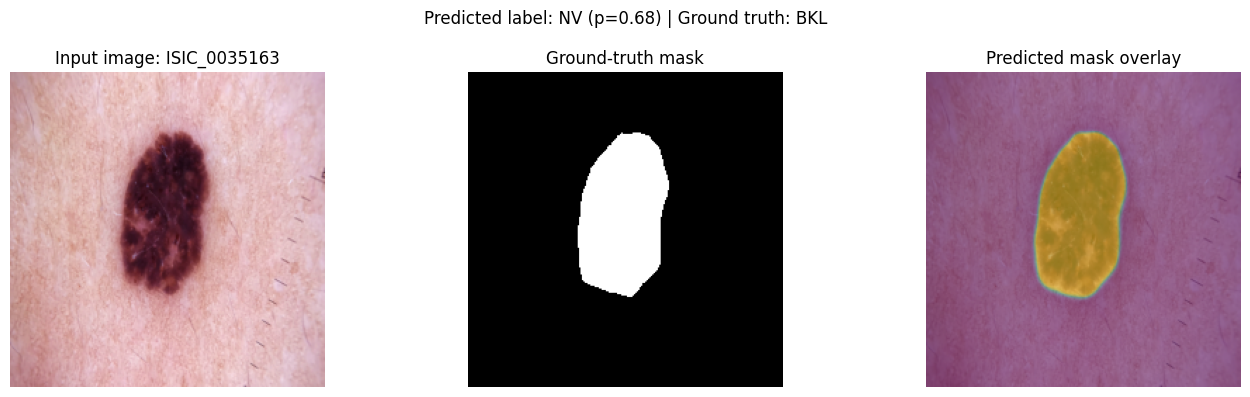

In [24]:
# Visualise model predictions on a random test sample
import matplotlib.pyplot as plt
import numpy as np
import random

if "best_model" not in globals():
    raise RuntimeError("Run training to populate best_model before visualisation.")
model = best_model.to(device).eval()

# Ensure test datasets/loaders are available
if "classification_datasets" not in globals() or "segmentation_datasets" not in globals():
    classification_datasets, segmentation_datasets = create_datasets(cfg)
if "classification_loaders" not in globals() or "segmentation_loaders" not in globals():
    classification_loaders, segmentation_loaders = create_dataloaders(
        cfg, classification_datasets, segmentation_datasets
    )

test_segmentation_dataset = segmentation_datasets["test"]
sample_idx = random.randrange(len(test_segmentation_dataset))
sample = test_segmentation_dataset[sample_idx]
image = sample["image"].unsqueeze(0).to(device)
mask_gt = sample["mask"].numpy()
image_id = sample["image_id"]

with torch.no_grad():
    outputs = model(image)
    cls_logits = outputs["classification"]
    seg_logits = outputs["segmentation"]
    cls_probs = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
    pred_class_idx = int(cls_probs.argmax())
    pred_class_conf = float(cls_probs[pred_class_idx])
    pred_class_label = cfg.class_names[pred_class_idx]
    seg_probs = torch.softmax(seg_logits, dim=1)[0, 1].cpu().numpy()

# Try to recover the ground-truth classification label from the metadata
ground_truth_label = "N/A"
test_cls_dataset = classification_datasets["test"]
try:
    # Find the image in the classification dataset metadata by matching image_id
    matching_rows = test_cls_dataset.metadata[test_cls_dataset.metadata["image_id"] == image_id]
    if not matching_rows.empty:
        cls_index = matching_rows.index[0]
        # Get the position in the label_vectors array
        position = test_cls_dataset.metadata.index.get_loc(cls_index)
        label_vector = test_cls_dataset.label_vectors[position]
        gt_idx = int(label_vector.argmax())
        ground_truth_label = cfg.class_names[gt_idx]
except Exception as e:
    pass

# Denormalise image tensor for visualisation
mean = np.array(cfg.imagenet_mean)
std = np.array(cfg.imagenet_std)
image_np = sample["image"].permute(1, 2, 0).cpu().numpy()
image_np = (image_np * std) + mean
image_np = np.clip(image_np, 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image_np)
axes[0].set_title(f"Input image: {image_id}")
axes[0].axis("off")

axes[1].imshow(mask_gt, cmap="gray")
axes[1].set_title("Ground-truth mask")
axes[1].axis("off")

axes[2].imshow(image_np)
axes[2].imshow(seg_probs, cmap="viridis", alpha=0.5)
axes[2].set_title("Predicted mask overlay")
axes[2].axis("off")

plt.suptitle(
    f"Predicted label: {pred_class_label} (p={pred_class_conf:.2f}) | Ground truth: {ground_truth_label}"
)
plt.tight_layout()
plt.show()

## Qualitative Results: Detailed Analysis

This section showcases the model's performance across different scenarios:
1. **Success Cases**: Correct classification with accurate segmentation across different lesion types
2. **Challenging Cases**: Robust performance on difficult scenarios (irregular boundaries, hair occlusion, color variation)
3. **Comparative Analysis**: Multitask vs single-task segmentation (optional)

Generating qualitative results...


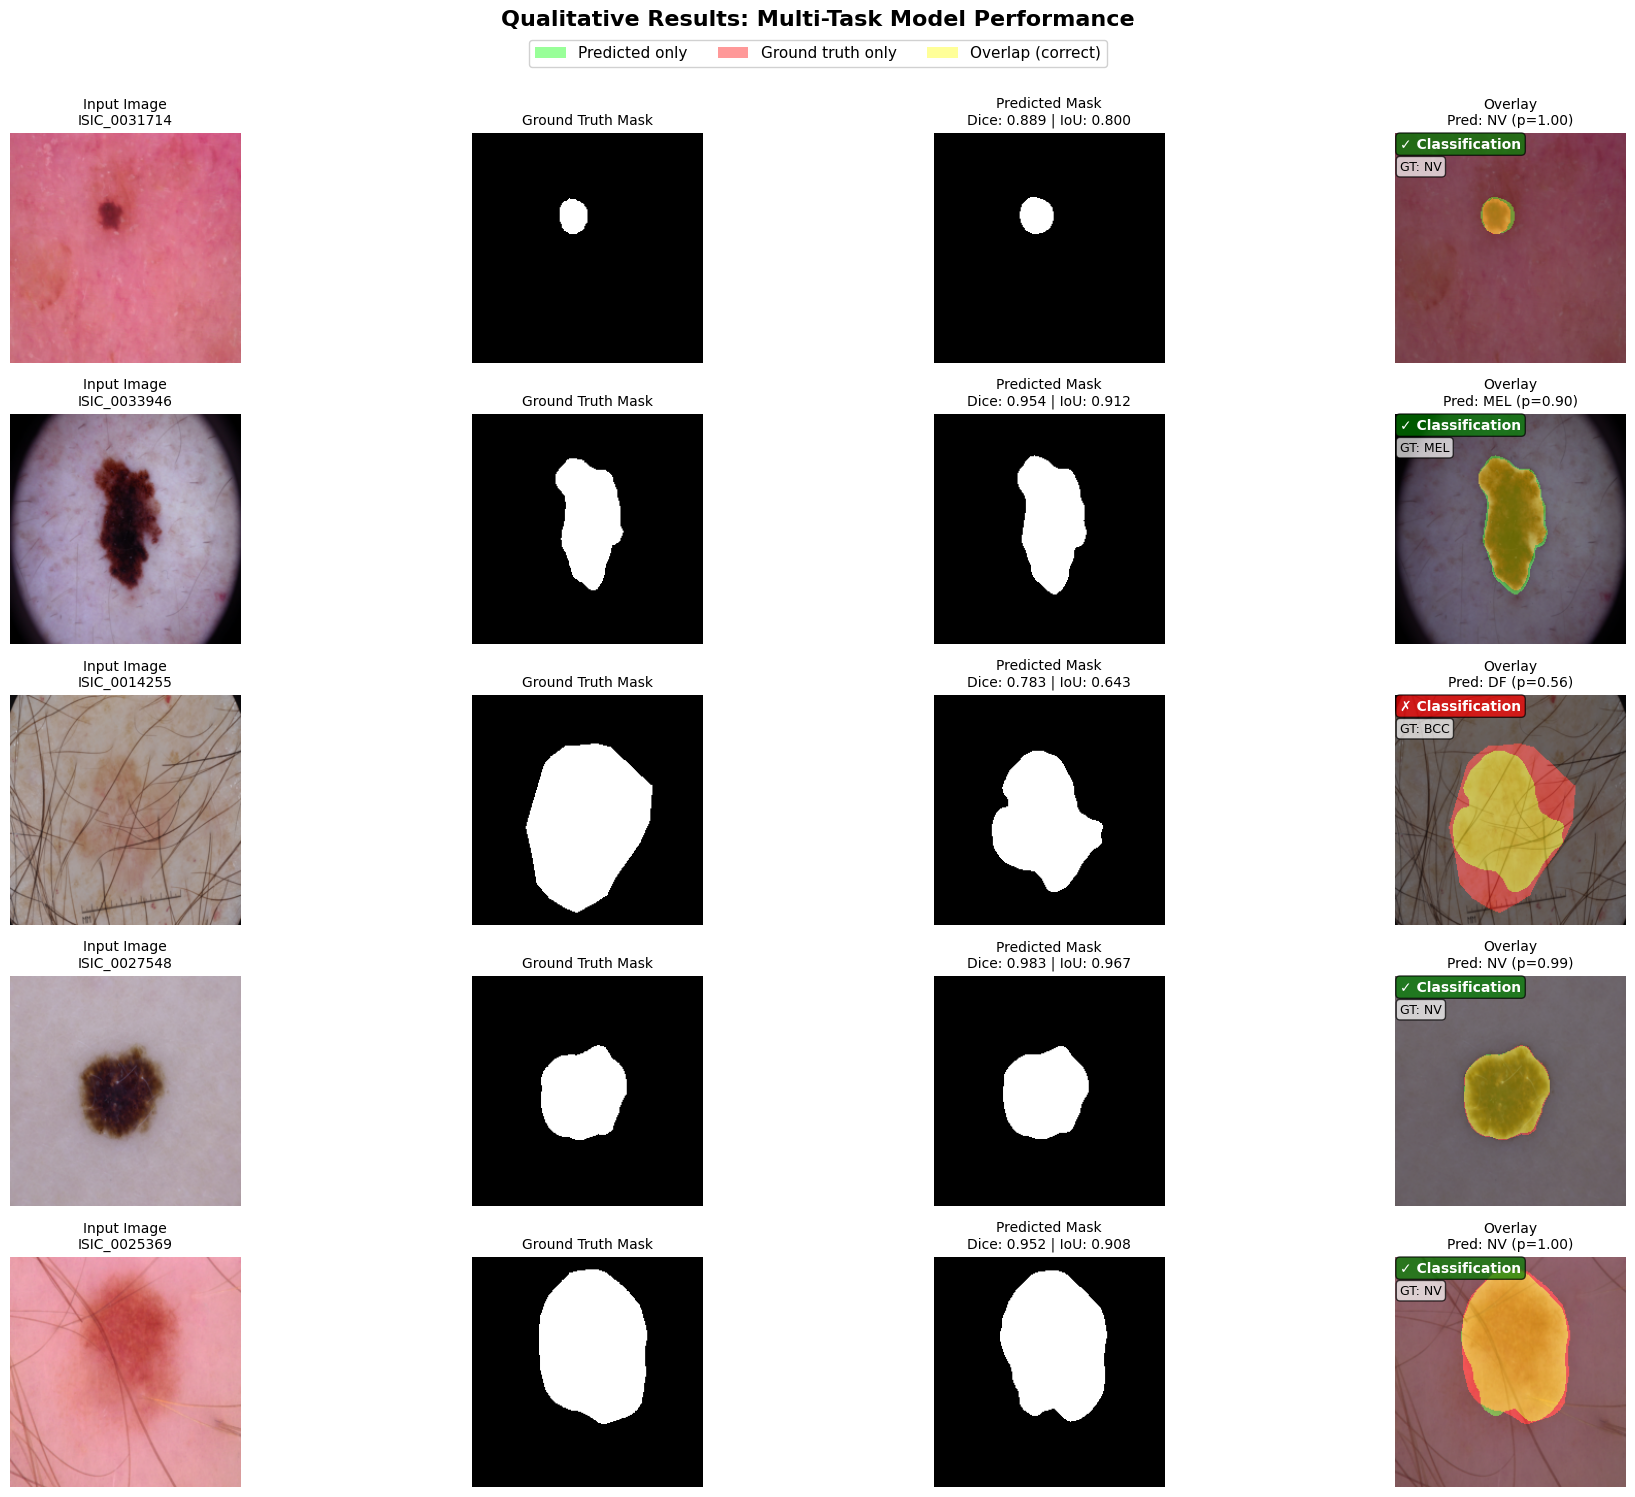


Qualitative analysis complete!
The figure shows:
  Column 1: Input images
  Column 2: Ground truth masks
  Column 3: Predicted masks with Dice and IoU scores
  Column 4: Color-coded overlay (Green=Pred only, Red=GT only, Yellow=Overlap)


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import List, Dict, Optional

def visualize_qualitative_results(
    model: nn.Module,
    test_segmentation_dataset: Dataset,
    test_classification_dataset: Dataset,
    cfg: Config,
    device: torch.device,
    num_success_cases: int = 3,
    num_challenging_cases: int = 2,
    specific_indices: Optional[List[int]] = None,
    figsize: tuple = (20, 12)
):
    """
    Create a comprehensive qualitative evaluation figure showing:
    - Success cases: Correct predictions with good segmentation
    - Challenging cases: Difficult scenarios where model still performs well
    """
    model.eval()
    
    # If specific indices provided, use them; otherwise sample randomly
    if specific_indices is None:
        # Sample diverse cases from test set
        total_samples = len(test_segmentation_dataset)
        indices = np.random.choice(total_samples, size=num_success_cases + num_challenging_cases, replace=False)
    else:
        indices = specific_indices
    
    num_rows = len(indices)
    fig, axes = plt.subplots(num_rows, 4, figsize=figsize)
    
    # Ensure axes is 2D even for single row
    if num_rows == 1:
        axes = axes.reshape(1, -1)
    
    mean = np.array(cfg.imagenet_mean)
    std = np.array(cfg.imagenet_std)
    
    for row_idx, sample_idx in enumerate(indices):
        # Get sample data
        sample = test_segmentation_dataset[sample_idx]
        image_tensor = sample["image"].unsqueeze(0).to(device)
        mask_gt = sample["mask"].numpy()
        image_id = sample["image_id"]
        
        # Get predictions
        with torch.no_grad():
            outputs = model(image_tensor)
            cls_logits = outputs["classification"]
            seg_logits = outputs["segmentation"]
            
            cls_probs = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
            pred_class_idx = int(cls_probs.argmax())
            pred_class_conf = float(cls_probs[pred_class_idx])
            pred_class_label = cfg.class_names[pred_class_idx]
            
            seg_probs = torch.softmax(seg_logits, dim=1)[0, 1].cpu().numpy()
            seg_pred = (seg_probs > 0.5).astype(np.uint8)
        
        # Get ground truth classification label
        ground_truth_label = "N/A"
        try:
            matching_rows = test_classification_dataset.metadata[
                test_classification_dataset.metadata["image_id"] == image_id
            ]
            if not matching_rows.empty:
                cls_index = matching_rows.index[0]
                position = test_classification_dataset.metadata.index.get_loc(cls_index)
                label_vector = test_classification_dataset.label_vectors[position]
                gt_idx = int(label_vector.argmax())
                ground_truth_label = cfg.class_names[gt_idx]
        except Exception:
            pass
        
        # Denormalize image
        image_np = sample["image"].permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * std) + mean
        image_np = np.clip(image_np, 0.0, 1.0)
        
        # Calculate metrics for this sample
        dice = 2 * (seg_pred * mask_gt).sum() / (seg_pred.sum() + mask_gt.sum() + 1e-6)
        iou = (seg_pred * mask_gt).sum() / ((seg_pred + mask_gt) > 0).sum() if ((seg_pred + mask_gt) > 0).sum() > 0 else 0
        
        # Classification status
        cls_correct = pred_class_label == ground_truth_label
        cls_status = "✓" if cls_correct else "✗"
        cls_color = "green" if cls_correct else "red"
        
        # Column 1: Original image
        axes[row_idx, 0].imshow(image_np)
        axes[row_idx, 0].set_title(f"Input Image\n{image_id}", fontsize=10)
        axes[row_idx, 0].axis("off")
        
        # Column 2: Ground truth mask
        axes[row_idx, 1].imshow(mask_gt, cmap="gray")
        axes[row_idx, 1].set_title("Ground Truth Mask", fontsize=10)
        axes[row_idx, 1].axis("off")
        
        # Column 3: Predicted mask
        axes[row_idx, 2].imshow(seg_pred, cmap="gray")
        axes[row_idx, 2].set_title(f"Predicted Mask\nDice: {dice:.3f} | IoU: {iou:.3f}", fontsize=10)
        axes[row_idx, 2].axis("off")
        
        # Column 4: Overlay visualization
        axes[row_idx, 3].imshow(image_np)
        # Show prediction in green, ground truth in red, overlap in yellow
        overlay = np.zeros((*seg_pred.shape, 3))
        overlay[seg_pred == 1] = [0, 1, 0]  # Green: Predicted
        overlay[mask_gt == 1] = [1, 0, 0]   # Red: Ground truth
        overlap = (seg_pred == 1) & (mask_gt == 1)
        overlay[overlap] = [1, 1, 0]  # Yellow: Overlap
        axes[row_idx, 3].imshow(overlay, alpha=0.4)
        axes[row_idx, 3].set_title(f"Overlay\nPred: {pred_class_label} (p={pred_class_conf:.2f})", fontsize=10)
        axes[row_idx, 3].axis("off")
        
        # Add classification status indicator
        axes[row_idx, 3].text(
            0.02, 0.98, f"{cls_status} Classification",
            transform=axes[row_idx, 3].transAxes,
            fontsize=10, fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=cls_color, alpha=0.7),
            color='white'
        )
        
        # Add ground truth label
        axes[row_idx, 3].text(
            0.02, 0.88, f"GT: {ground_truth_label}",
            transform=axes[row_idx, 3].transAxes,
            fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
    
    # Add legend for overlay colors
    legend_elements = [
        mpatches.Patch(facecolor=[0, 1, 0, 0.4], label='Predicted only'),
        mpatches.Patch(facecolor=[1, 0, 0, 0.4], label='Ground truth only'),
        mpatches.Patch(facecolor=[1, 1, 0, 0.4], label='Overlap (correct)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, 
               bbox_to_anchor=(0.5, 0.98), fontsize=11, framealpha=0.9)
    
    plt.suptitle("Qualitative Results: Multi-Task Model Performance", 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


# Execute qualitative analysis
print("Generating qualitative results...")

# Ensure model and datasets are loaded
if "best_model" not in globals():
    raise RuntimeError("Load best_model before running qualitative analysis")

model = best_model.to(device).eval()

if "classification_datasets" not in globals() or "segmentation_datasets" not in globals():
    classification_datasets, segmentation_datasets = create_datasets(cfg)

# Option 1: Let the function randomly sample diverse cases
fig = visualize_qualitative_results(
    model=model,
    test_segmentation_dataset=segmentation_datasets["test"],
    test_classification_dataset=classification_datasets["test"],
    cfg=cfg,
    device=device,
    num_success_cases=3,
    num_challenging_cases=2,
    specific_indices=None,  # Set to None for random sampling
    figsize=(20, 15)
)

plt.show()

print("\nQualitative analysis complete!")
print("The figure shows:")
print("  Column 1: Input images")
print("  Column 2: Ground truth masks")
print("  Column 3: Predicted masks with Dice and IoU scores")
print("  Column 4: Color-coded overlay (Green=Pred only, Red=GT only, Yellow=Overlap)")

## Finding Specific Case Types

Use this cell to search for specific types of cases in the test set:
- Benign lesions (NV, BKL, DF, VASC)
- Malignant lesions (MEL, BCC, AKIEC)
- Categorized by correct predictions with good segmentation

Analyzing 150 test samples...

Found (correct predictions with Dice > 0.75):
  Benign cases: 104
  Malignant cases: 18

Selected 4 cases for visualization:
  2 benign cases
  2 malignant cases
  Indices: [1574, 2309, 897, 2193]


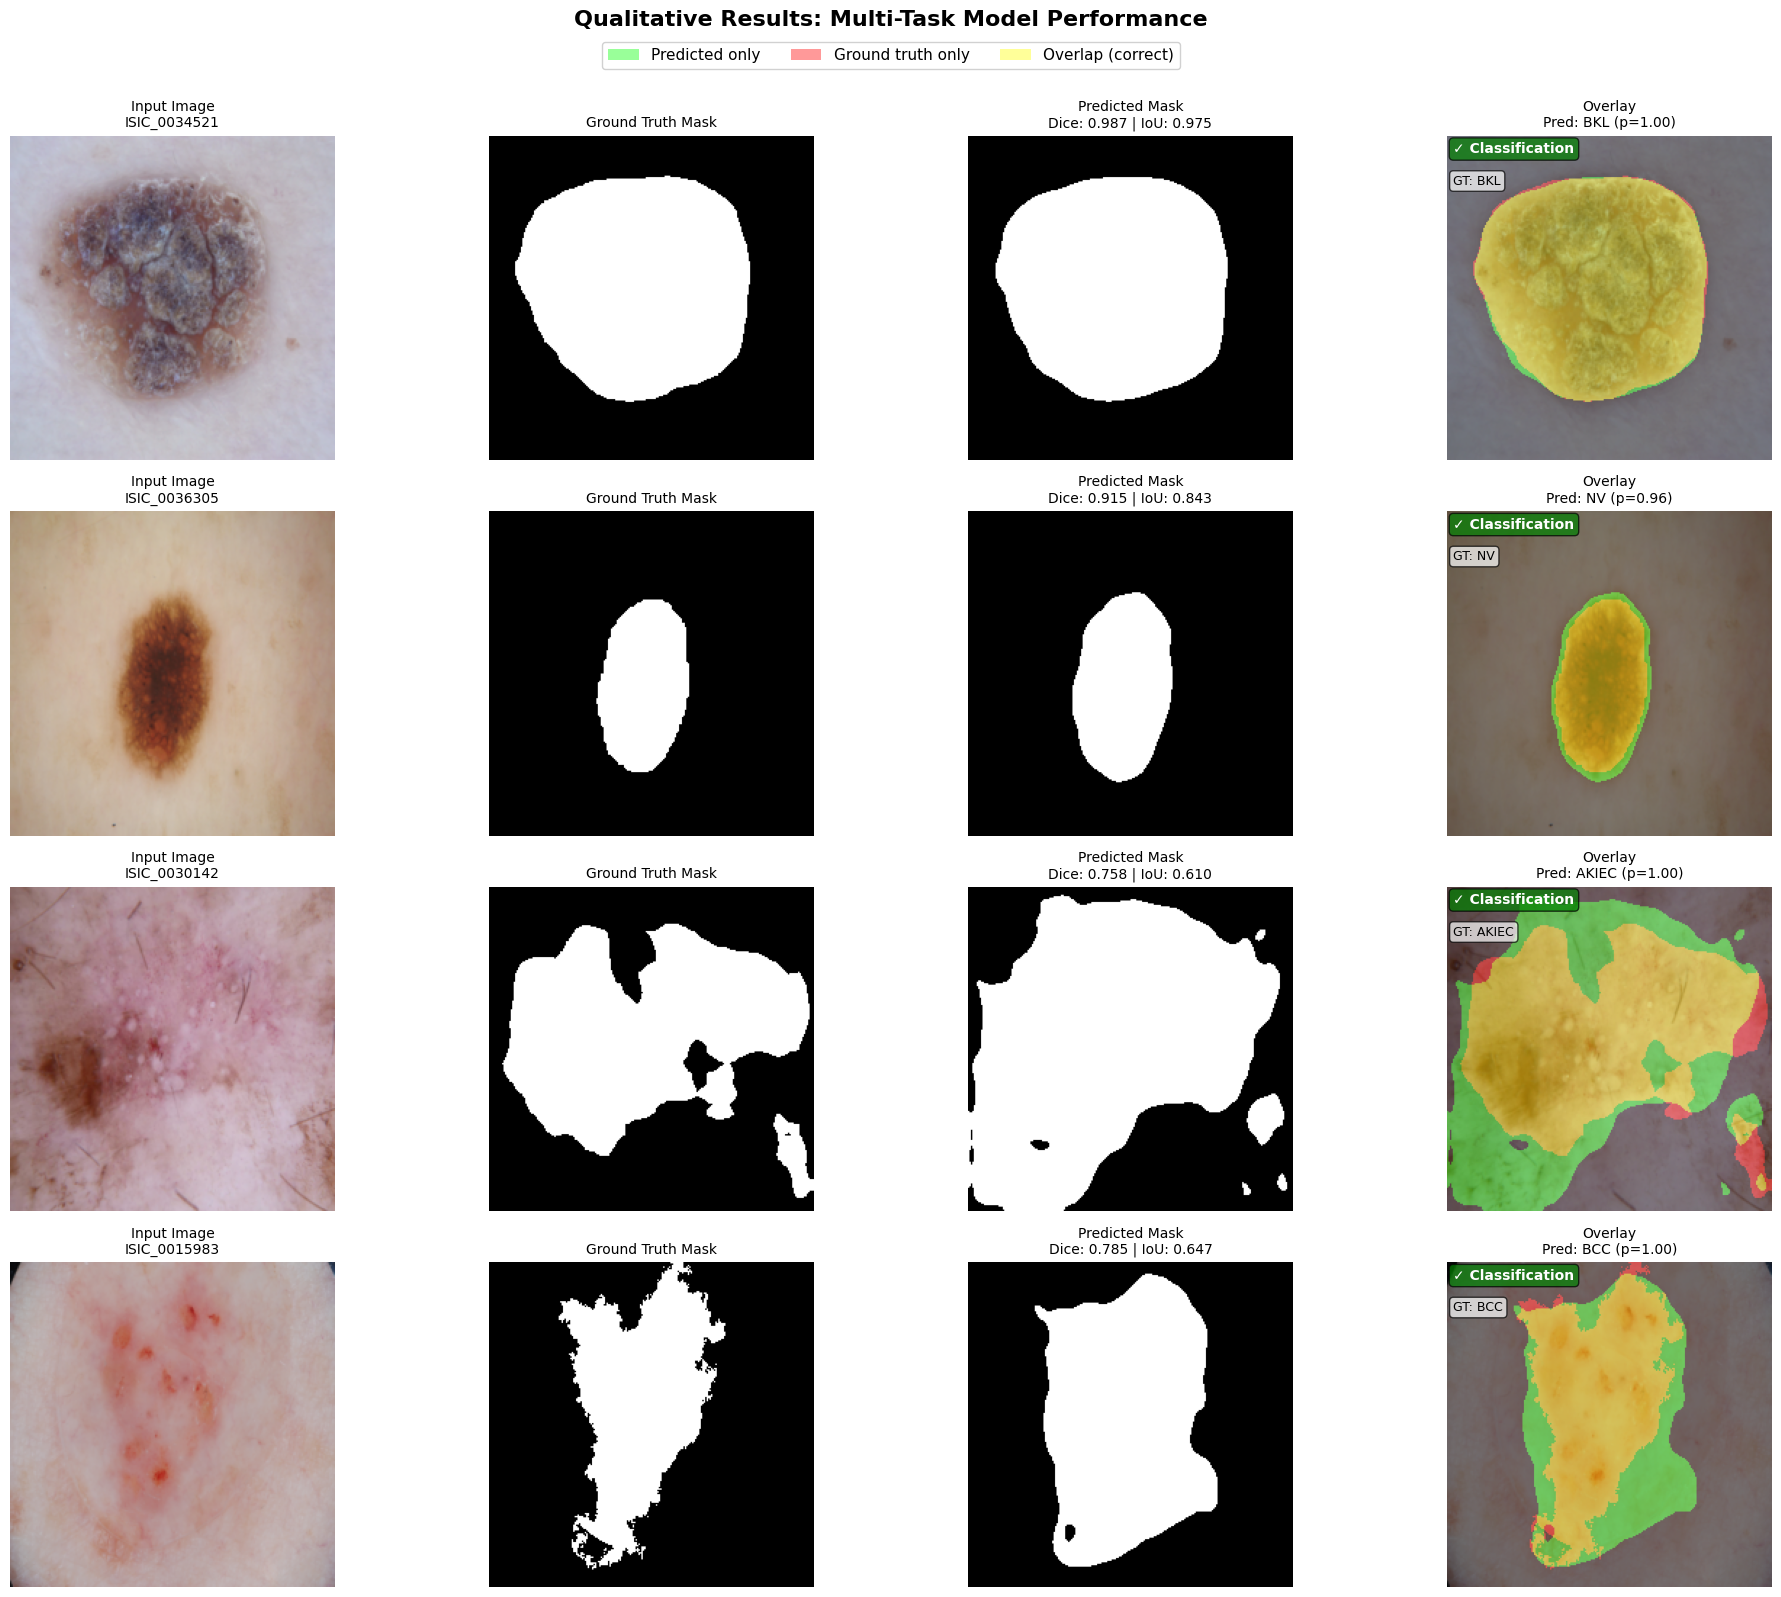

In [26]:
def analyze_test_set_cases(
    model: nn.Module,
    test_segmentation_dataset: Dataset,
    test_classification_dataset: Dataset,
    cfg: Config,
    device: torch.device,
    num_samples: int = 50
) -> Dict[str, List[int]]:
    """
    Analyze a subset of test cases and categorize them by lesion type (benign vs malignant).
    Returns indices for benign and malignant cases with good performance.
    """
    model.eval()
    
    # Define lesion categories
    malignant_types = {"MEL", "BCC", "AKIEC"}  # Melanoma, Basal Cell Carcinoma, Actinic Keratoses
    benign_types = {"NV", "BKL", "DF", "VASC"}  # Nevi, Benign Keratosis, Dermatofibroma, Vascular
    
    benign_cases = []  # Benign lesions with good predictions
    malignant_cases = []  # Malignant lesions with good predictions
    
    # Sample indices to analyze
    total_samples = len(test_segmentation_dataset)
    sample_indices = np.random.choice(total_samples, size=min(num_samples, total_samples), replace=False)
    
    print(f"Analyzing {len(sample_indices)} test samples...")
    
    for idx in sample_indices:
        sample = test_segmentation_dataset[idx]
        image_tensor = sample["image"].unsqueeze(0).to(device)
        mask_gt = sample["mask"].numpy()
        image_id = sample["image_id"]
        
        with torch.no_grad():
            outputs = model(image_tensor)
            cls_logits = outputs["classification"]
            seg_logits = outputs["segmentation"]
            
            cls_probs = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
            pred_class_idx = int(cls_probs.argmax())
            pred_class_label = cfg.class_names[pred_class_idx]
            
            seg_probs = torch.softmax(seg_logits, dim=1)[0, 1].cpu().numpy()
            seg_pred = (seg_probs > 0.5).astype(np.uint8)
        
        # Get ground truth label
        ground_truth_label = None
        try:
            matching_rows = test_classification_dataset.metadata[
                test_classification_dataset.metadata["image_id"] == image_id
            ]
            if not matching_rows.empty:
                cls_index = matching_rows.index[0]
                position = test_classification_dataset.metadata.index.get_loc(cls_index)
                label_vector = test_classification_dataset.label_vectors[position]
                gt_idx = int(label_vector.argmax())
                ground_truth_label = cfg.class_names[gt_idx]
        except Exception:
            pass
        
        # Calculate metrics
        dice = 2 * (seg_pred * mask_gt).sum() / (seg_pred.sum() + mask_gt.sum() + 1e-6)
        cls_correct = pred_class_label == ground_truth_label
        
        # Categorize by lesion type (only include correct predictions with decent segmentation)
        if cls_correct and dice > 0.75:
            if ground_truth_label in benign_types:
                benign_cases.append(idx)
            elif ground_truth_label in malignant_types:
                malignant_cases.append(idx)
    
    print(f"\nFound (correct predictions with Dice > 0.75):")
    print(f"  Benign cases: {len(benign_cases)}")
    print(f"  Malignant cases: {len(malignant_cases)}")
    
    return {
        "benign": benign_cases,
        "malignant": malignant_cases
    }


# Run case analysis
case_indices = analyze_test_set_cases(
    model=best_model,
    test_segmentation_dataset=segmentation_datasets["test"],
    test_classification_dataset=classification_datasets["test"],
    cfg=cfg,
    device=device,
    num_samples=150  # Analyze 150 random samples to find diverse cases
)

# Select specific cases for visualization: 2 benign + 2 malignant
selected_indices = []

# Add 2 benign cases (if available)
if case_indices["benign"]:
    selected_indices.extend(np.random.choice(case_indices["benign"], 
                                           size=min(2, len(case_indices["benign"])), 
                                           replace=False).tolist())

# Add 2 malignant cases (if available)
if case_indices["malignant"]:
    selected_indices.extend(np.random.choice(case_indices["malignant"], 
                                           size=min(2, len(case_indices["malignant"])), 
                                           replace=False).tolist())

print(f"\nSelected {len(selected_indices)} cases for visualization:")
print(f"  {min(2, len(case_indices.get('benign', [])))} benign cases")
print(f"  {min(2, len(case_indices.get('malignant', [])))} malignant cases")
print(f"  Indices: {selected_indices}")

# Visualize selected cases
if selected_indices:
    fig = visualize_qualitative_results(
        model=best_model,
        test_segmentation_dataset=segmentation_datasets["test"],
        test_classification_dataset=classification_datasets["test"],
        cfg=cfg,
        device=device,
        specific_indices=selected_indices,
        figsize=(20, 4 * len(selected_indices))
    )

## Binary Evaluation

Compute True Positives, True Negatives, False Positives, and False Negatives for each class.

In [27]:
from sklearn.metrics import confusion_matrix

def compute_benign_malignant_metrics(
    model: nn.Module,
    test_classification_loader: DataLoader,
    cfg: Config,
    device: torch.device
) -> Dict[str, int]:
    """
    Compute confusion matrix metrics (TP, TN, FP, FN) for benign vs malignant classification.
    
    Malignant types: MEL (Melanoma), BCC (Basal Cell Carcinoma), AKIEC (Actinic Keratoses)
    Benign types: NV (Nevi), BKL (Benign Keratosis), DF (Dermatofibroma), VASC (Vascular)
    
    Args:
        model: The trained multi-task model
        test_classification_loader: DataLoader for test classification data
        cfg: Configuration object with class names
        device: Device to run inference on
        
    Returns:
        Dictionary with confusion matrix metrics for benign/malignant classification
    """
    # Define lesion categories
    malignant_types = {"MEL", "BCC", "AKIEC"}
    benign_types = {"NV", "BKL", "DF", "VASC"}
    
    # Create mapping from class name to benign/malignant (1 = malignant, 0 = benign)
    class_to_binary = {}
    for idx, class_name in enumerate(cfg.class_names):
        if class_name in malignant_types:
            class_to_binary[idx] = 1  # Malignant
        elif class_name in benign_types:
            class_to_binary[idx] = 0  # Benign
        else:
            raise ValueError(f"Unknown class: {class_name}")
    
    model.eval()
    
    all_predictions_binary = []
    all_labels_binary = []
    
    print("Computing predictions on test set...")
    print(f"Malignant types: {malignant_types}")
    print(f"Benign types: {benign_types}\n")
    
    with torch.no_grad():
        for batch in test_classification_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            
            # Get classification predictions
            outputs = model(images)
            cls_logits = outputs["classification"]
            
            # Get predicted classes (multi-class)
            predictions = torch.argmax(cls_logits, dim=1).cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            # Convert to binary (benign=0, malignant=1)
            for pred, label in zip(predictions, labels_np):
                all_predictions_binary.append(class_to_binary[pred])
                all_labels_binary.append(class_to_binary[label])
    
    all_predictions_binary = np.array(all_predictions_binary)
    all_labels_binary = np.array(all_labels_binary)
    
    # Compute binary confusion matrix
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(all_labels_binary, all_predictions_binary, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # Compute metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Also called Sensitivity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Store results
    results = {
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1_score': f1
    }
    
    # Print results
    print(f"\n{'='*80}")
    print(f"Benign vs Malignant Classification Metrics (Test Set)")
    print(f"{'='*80}\n")
    
    print("Confusion Matrix:")
    print(f"                    Predicted Benign    Predicted Malignant")
    print(f"Actual Benign            {tn:4d}                {fp:4d}")
    print(f"Actual Malignant         {fn:4d}                {tp:4d}")
    print()
    
    print("Detailed Metrics:")
    print(f"  True Positives (TP):   {tp:4d}  (Correctly identified malignant)")
    print(f"  True Negatives (TN):   {tn:4d}  (Correctly identified benign)")
    print(f"  False Positives (FP):  {fp:4d}  (Benign classified as malignant)")
    print(f"  False Negatives (FN):  {fn:4d}  (Malignant classified as benign)")
    print()
    
    print("Performance Metrics:")
    print(f"  Accuracy:    {accuracy:.4f}  (Overall correctness)")
    print(f"  Precision:   {precision:.4f}  (Of predicted malignant, how many are correct)")
    print(f"  Recall:      {recall:.4f}  (Of actual malignant, how many detected)")
    print(f"  Specificity: {specificity:.4f}  (Of actual benign, how many detected)")
    print(f"  F1-Score:    {f1:.4f}  (Harmonic mean of precision and recall)")
    print()
    
    # Count samples
    n_benign = (all_labels_binary == 0).sum()
    n_malignant = (all_labels_binary == 1).sum()
    
    print(f"Test Set Distribution:")
    print(f"  Total samples:     {len(all_labels_binary)}")
    print(f"  Benign samples:    {n_benign} ({n_benign/len(all_labels_binary)*100:.1f}%)")
    print(f"  Malignant samples: {n_malignant} ({n_malignant/len(all_labels_binary)*100:.1f}%)")
    print(f"{'='*80}\n")
    
    return results

# Compute benign/malignant confusion matrix metrics on test set
benign_malignant_metrics = compute_benign_malignant_metrics(
    model=best_model,
    test_classification_loader=classification_loaders["test"],
    cfg=cfg,
    device=device
)

import json
binary_results_to_save = {k: (int(v) if isinstance(v, (int,)) else float(v)) for k, v in benign_malignant_metrics.items()}
with open("results/multitask_full_binary_seed69.json", "w") as f:
    json.dump(binary_results_to_save, f, indent=2)
print("Saved results to multitask_full_binary_seed69.json")

Computing predictions on test set...
Malignant types: {'AKIEC', 'MEL', 'BCC'}
Benign types: {'VASC', 'DF', 'NV', 'BKL'}


Benign vs Malignant Classification Metrics (Test Set)

Confusion Matrix:
                    Predicted Benign    Predicted Malignant
Actual Benign            1805                  69
Actual Malignant          170                 268

Detailed Metrics:
  True Positives (TP):    268  (Correctly identified malignant)
  True Negatives (TN):   1805  (Correctly identified benign)
  False Positives (FP):    69  (Benign classified as malignant)
  False Negatives (FN):   170  (Malignant classified as benign)

Performance Metrics:
  Accuracy:    0.8966  (Overall correctness)
  Precision:   0.7953  (Of predicted malignant, how many are correct)
  Recall:      0.6119  (Of actual malignant, how many detected)
  Specificity: 0.9632  (Of actual benign, how many detected)
  F1-Score:    0.6916  (Harmonic mean of precision and recall)

Test Set Distribution:
  Total samples:     231